In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import dtreeviz
from umap import UMAP
from scipy import stats
from scipy.stats import skew, kurtosis, ttest_ind
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, silhouette_samples, silhouette_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cluster import KMeans, DBSCAN
from scipy.spatial.distance import cdist
from skopt.space import Integer, Real, Categorical
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
import shap
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="pastel")

In [3]:

cases_df = pd.read_csv('data\\cases_df.csv', index_col=0)
cases_df_op = pd.read_csv("data\\case_df_op.csv", index_col=0)
cases_df.drop_duplicates(inplace=True)
cases_df_op.drop_duplicates(inplace=True)

cases_df_op.dropna(subset=[col for col in cases_df_op.columns if col not in ("Stability", "case_id")], how= 'all', inplace=True)
cases_df_op.fillna(0, inplace=True)
columns_in_df = cases_df.columns

df_taus = (
    cases_df_op[['case_id']]
    .merge(cases_df[[col for col in columns_in_df if col.startswith('tau_droop')]+['case_id']], 
           on='case_id', how='left')
)

df_Sn_GFOL = cases_df_op.filter(regex='^Sn_GFOL').reset_index(drop=True)
df_taus_GFOL_droopf = df_taus[['tau_droop_f_gfol_'+col.split('GFOL')[1] for col in df_Sn_GFOL.columns]]
df_taus_GFOL_droopu = df_taus[['tau_droop_u_gfol_'+col.split('GFOL')[1] for col in df_Sn_GFOL.columns]]
df_taus_GFOL_droopf[np.array(df_Sn_GFOL==0)]=0
df_taus_GFOL_droopu[np.array(df_Sn_GFOL==0)]=0

df_Sn_GFOR = cases_df_op.filter(regex='^Sn_GFOR').reset_index(drop=True)
df_taus_GFOR_droopf = df_taus[['tau_droop_f_gfor_'+col.split('GFOR')[1] for col in df_Sn_GFOR.columns]]
df_taus_GFOR_droopu = df_taus[['tau_droop_u_gfor_'+col.split('GFOR')[1] for col in df_Sn_GFOR.columns]]
df_taus_GFOR_droopf[np.array(df_Sn_GFOR==0)]=0
df_taus_GFOR_droopu[np.array(df_Sn_GFOR==0)]=0

df_taus_fixed = pd.concat([df_taus_GFOL_droopf,df_taus_GFOL_droopu,df_taus_GFOR_droopf,df_taus_GFOR_droopu],axis=1)

df_taus_fixed['Stability'] = cases_df_op['Stability'].reset_index(drop=True)
df_taus_fixed['case_id'] = cases_df_op['case_id'].reset_index(drop=True)


# MÈTODES

## 1. Exploració inicial i anàlisi bàsic 

### Preprocessament (fine_df)

Després de veure aquest anàlisis de les dades procediré a obtenir un conjunt de dades que li dire *fine_df* en el qual s'eliminaràn totes es variables que s'han trobat que no aporten informació rellevant, són constants, etc.

Tot i tenir el conjunt *fine_df* mantindré el conjunt original per veure si relament la neteja de dades irrellevants suposa una ajuda a l'hora de treballar amb les dades o la perdua d'informació és important. 

In [4]:
fine_df = cases_df_op.merge(df_taus_fixed.drop("Stability", axis=1), on='case_id', how='left')
fine_df.drop("case_id", axis=1, inplace=True)
fine_df.dropna(subset=[col for col in fine_df.columns if col != "Stability"], how= 'all', inplace=True)
fine_df.fillna(0, inplace=True)
orig_df = fine_df.copy()
fine_df.shape

(5714, 740)

#### 1. Eliminar constants

Previament s'ha vist que totes les variables Sn_SGX són constants i per tant es poden eliminar.

In [5]:
const_cols = fine_df.loc[:, np.isclose(fine_df.std(), 0)].columns.tolist()
print(f"Columnes constants: {const_cols}")
print(f"Nombre de columnes constants: {len(const_cols)}")
fine_df.drop(columns=const_cols, inplace=True)
fine_num_cols = fine_df.select_dtypes(include=np.number).columns.tolist()
fine_df = fine_df[fine_num_cols]

X = fine_df.drop(columns=['Stability'])
y = fine_df['Stability']

Columnes constants: ['Sn_SG12', 'Sn_SG103', 'Sn_SG34', 'Sn_SG74', 'Sn_SG112', 'Sn_SG107', 'Sn_SG36', 'Sn_SG66', 'Sn_SG46', 'Sn_SG49', 'Sn_SG25', 'Sn_SG113', 'Sn_SG26', 'Sn_SG10', 'Sn_SG4', 'Sn_SG100', 'Sn_SG89', 'Sn_SG90', 'Sn_SG87', 'Sn_SG65', 'Sn_SG18', 'Sn_SG6', 'Sn_SG8', 'Sn_SG85', 'Sn_SG91', 'Sn_SG40', 'Sn_SG62', 'Sn_SG55', 'Sn_SG111', 'Sn_SG42', 'Sn_SG54', 'Sn_SG56', 'Sn_SG76', 'Sn_SG59', 'Sn_SG61', 'Sn_SG77', 'Sn_SG99', 'Sn_SG80', 'Sn_SG32', 'Sn_SG116', 'Sn_SG69', 'Sn_SG92', 'Sn_SG105', 'Sn_SG19', 'Sn_SG70', 'Sn_SG72', 'Sn_SG24']
Nombre de columnes constants: 47


#### 2. Transformar segons skewness i kurtosis

Segons el valor de skewness i kurtosis podem:

| Mètrica  | Valor (abs)   | Què indica                         | Possible acció                 |    
| -------- | ------------- | ---------------------------------- | ------------------------------ | 
| Skewness | < 1           | Simetria                           |                                |    
|          | 1–2           | Asimetria moderada                 |                                |    
|          | >2            | Asimetria forta                    | Transformar                    |    
| Kurtosis | 2–4           | Normal                             |                                |   
|          | >7            | Molta concentració o cues llargues | Transformar / revisar outliers |   




In [6]:
skewness = abs(X.apply(skew))
kurt = abs(X.apply(kurtosis))

dist_summary = pd.DataFrame({'skewness': skewness, 'kurtosis': kurt})
dist_summary.sort_values(['skewness', 'kurtosis'], inplace=True)
cols_to_transform = dist_summary[(dist_summary['skewness'] > 2) | (dist_summary['kurtosis'] > 7)].index.tolist()
print(dist_summary)
print(f"Nombre de columnes a transformar: {len(cols_to_transform)}")

                       skewness     kurtosis
tau_droop_f_gfol_19    0.001586     1.199635
tau_droop_u_gfol_55    0.001665     1.184140
tau_droop_f_gfol_24    0.002351     1.193861
tau_droop_u_gfol_112   0.002592     1.169531
V22                    0.002783     1.471668
...                         ...          ...
theta48               29.853590  1666.956215
theta49               31.148502  1393.559752
theta73               31.308803  1785.605288
theta71               31.308803  1785.605288
theta45               32.307072  1865.406638

[692 rows x 2 columns]
Nombre de columnes a transformar: 152


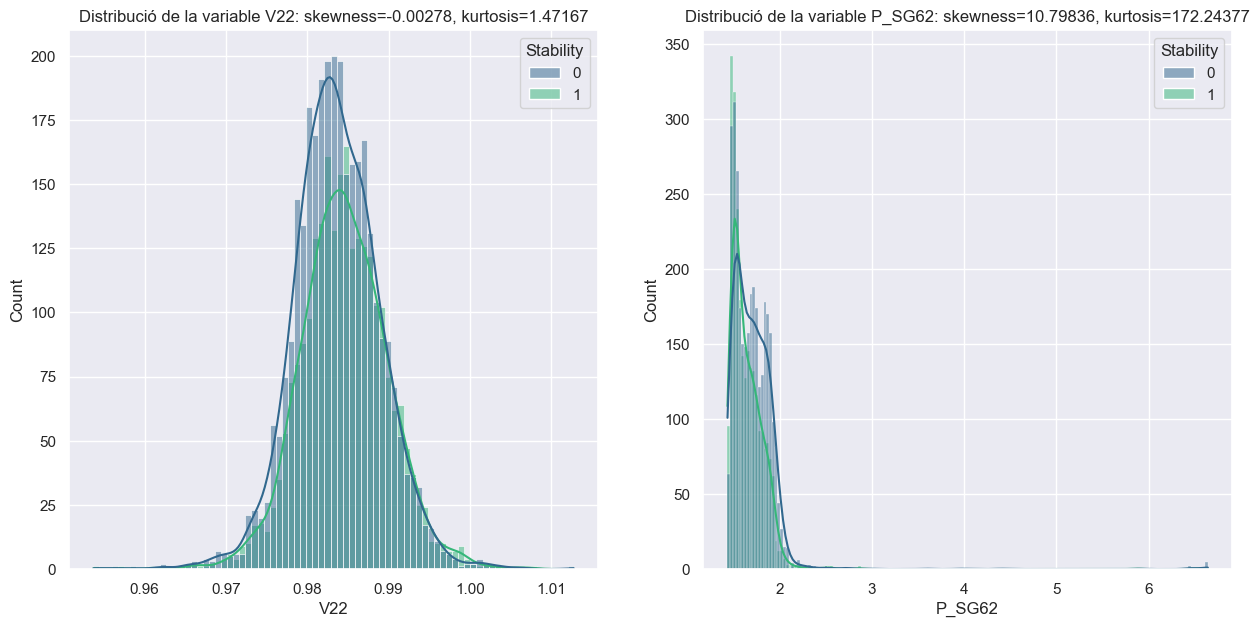

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(fine_df, x=X["V22"], kde=True, hue="Stability", palette="viridis", ax=ax[0])
ax[0].set_title(f"Distribució de la variable V22: skewness={skew(X['V22']).round(5)}, kurtosis={kurtosis(X['V22']).round(5)}")
sns.histplot(fine_df, x=X["P_SG62"],kde=True, hue="Stability", palette="viridis", ax=ax[1])
ax[1].set_title(f"Distribució de la variable P_SG62: skewness={skew(X['P_SG62']).round(5)}, kurtosis={kurtosis(X['P_SG62']).round(5)}")
plt.show()


In [8]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)

X_norm = X.copy()
X_norm[cols_to_transform] = pt.fit_transform(X[cols_to_transform])

skewness = abs(X_norm.apply(skew))
kurt = abs(X_norm.apply(kurtosis))

dist_summary = pd.DataFrame({'skewness': skewness, 'kurtosis': kurt})
dist_summary.sort_values(['skewness', 'kurtosis'], inplace=True)

print(dist_summary)

                      skewness    kurtosis
theta26               0.000247    4.929645
tau_droop_f_gfol_19   0.001586    1.199635
tau_droop_u_gfol_55   0.001665    1.184140
tau_droop_f_gfol_24   0.002351    1.193861
tau_droop_u_gfol_112  0.002592    1.169531
...                        ...         ...
theta101              2.603164   14.651192
theta100              2.605938   15.117866
theta88               2.607072   15.905804
theta103              2.610413   14.930029
theta87               8.386645  146.270658

[692 rows x 2 columns]


#### 3. Eliminar outliers

In [9]:
iso_forest = IsolationForest(n_estimators=500, contamination=0.05, random_state=42).fit(X_norm)
pred = iso_forest.predict(X_norm)
outlier_rows = pred == -1
print("Nombre d'outliers detectats:", outlier_rows.sum())
X_clean = X_norm[~outlier_rows]
y_clean = y[~outlier_rows]

Nombre d'outliers detectats: 286


In [10]:
X_clean.shape, y_clean.shape

((5428, 692), (5428,))

#### 4. Eliminar segons t-test

Ja que no vull destruir massa informació utilitzaré un llindar de p_value de 0.2 pel t-test per tenir cert marge

In [11]:
p_thresh = 0.2
t_stats = []
p_values = []
for col in X_clean.columns:
    group1 = X_clean[y_clean == 0][col]
    group2 = X_clean[y_clean == 1][col]
    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
    t_stats.append(t_stat)
    p_values.append(abs(p_value))

res = pd.DataFrame({'t_stat': t_stats, 'p_value': p_values}, index=X_clean.columns)
print(res.sort_values(by='p_value', ascending=False))
select_res = res[res['p_value'] <= p_thresh].index.tolist()
cols_to_drop = res[res['p_value'] > p_thresh].index.tolist()
print(f"Nombre de columnes a borrar: {len(cols_to_drop)}")
X_final = X_clean[select_res]
X_final.shape

                         t_stat        p_value
Q_SG80                 0.000000   1.000000e+00
tau_droop_u_gfol_110  -0.005850   9.953324e-01
theta112               0.006182   9.950679e-01
Q_SG92                -0.013886   9.889214e-01
tau_droop_f_gfol_18   -0.047299   9.622766e-01
...                         ...            ...
P_GFOR112            -31.135160  8.288637e-196
Sn_GFOL112            37.355078  5.295548e-272
Sn_GFOR112           -37.355078  5.295548e-272
Q_GFOL112             42.053323   0.000000e+00
P_GFOL112             42.172325   0.000000e+00

[692 rows x 2 columns]
Nombre de columnes a borrar: 51


(5428, 641)

#### 5. Escalar les dades

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
y_scaled = y_clean.copy()

## 2. PCA – Principal Component Analysis

<p align="left">
<img src="img/pca.png" alt="PCA plot" width="38%" style="float: right; margin-left: 100px; margin-right:100px;">
Permet trobar i visualitzar les direccions demàxima variància de les dades.
Objectius:

- Reduir dimensionalitat
- Veure l’estructura global (eixos principals) de les dades

Limitacions:

- Assumeix relació lineal 
- Sensible a outlaiers
- Necessita normalització
- Poca interpretablititat quan hi ha masses components principals

Alternatives: Kernel PCA i Sparse KPCA
</p>

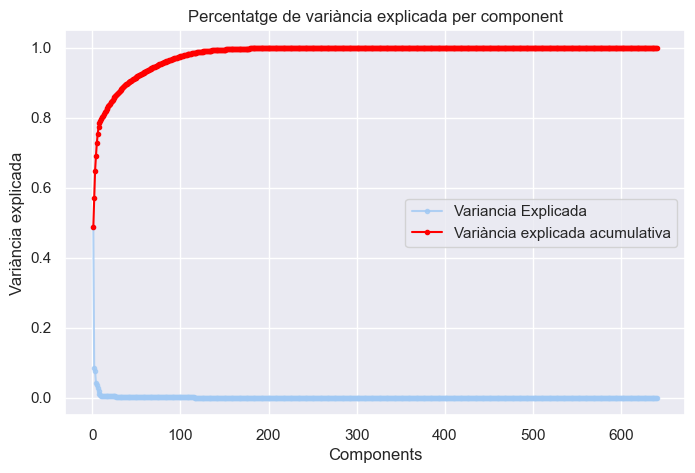

In [12]:
pca = PCA().fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1,len(pca.explained_variance_ratio_ )+1),pca.explained_variance_ratio_ ,alpha=0.8,marker='.',label="Variancia Explicada");
y_label = plt.ylabel('Variància explicada');
x_label = plt.xlabel('Components');
plt.plot(range(1,len(pca.explained_variance_ratio_ )+1),
         np.cumsum(pca.explained_variance_ratio_),
         c='red',marker='.',
         label="Variància explicada acumulativa");
plt.legend();
plt.title('Percentatge de variància explicada per component');
plt.show()

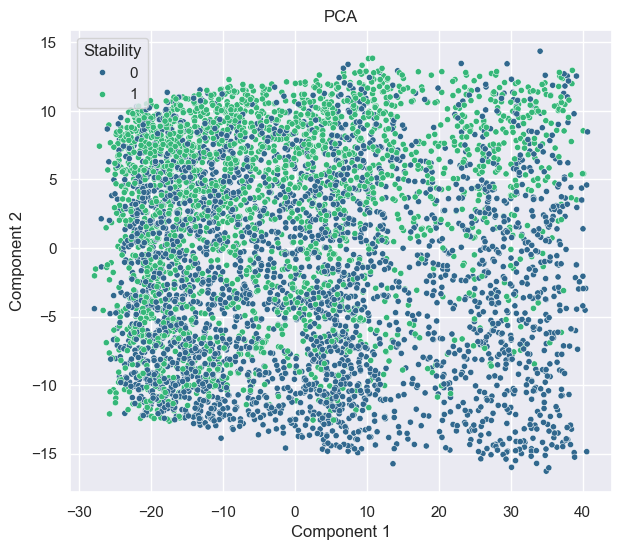

In [13]:
X_pca = pca.transform(X_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_scaled, s=20, palette='viridis');
plt.title('PCA')
plt.ylabel('Component 2')
plt.xlabel('Component 1')
plt.show()


In [14]:
X_pca = PCA(n_components=50).fit_transform(X_scaled)

## 3. t-SNE – t-distributed Stochastic Neighbor Embedding


<p align="left">
<img src="img/tsne.png" alt="PCA plot" width="35%" style="float: right; margin-left: 100px; margin-right:100px;">
Consisteix en convertir les “similituds” dels punts en un espai de probabilitats i llavors trobar una configuració de dimensionalitat reduïda que reprodueixi el mateix espai.

Objectius:

- Veure si les dades son separables (clústers)

Limitacions:

- Cost
- Fixar seed per reproductibilitat
- No preserva l'estructura
- Resultats no detarministes, seed diferent => resultats diferents
- Problemes amb moltes variables (aplicar primer reducció de dimensionalitat)

Alternatives: Barnes-Hut i Fit t-SNE
</p>

In [15]:
tsne = TSNE(random_state=42).fit_transform(X_scaled)
tsne_pca = TSNE(random_state=42).fit_transform(X_pca)

  File "C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


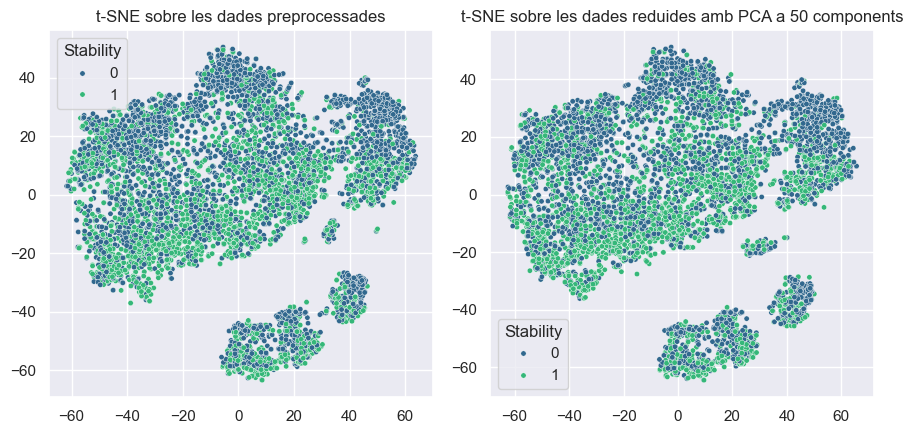

In [16]:
fig, ax = plt.subplots(1,2,figsize=(9,4.5))
sns.scatterplot(x=tsne[:,0], y=tsne[:,1], hue=y_scaled, palette="viridis",s=15, ax=ax[0]);
sns.scatterplot(x=tsne_pca[:,0], y=tsne_pca[:,1], hue=y_scaled, palette="viridis", s=15, ax=ax[1]);
ax[0].set_title('t-SNE sobre les dades preprocessades')
ax[1].set_title('t-SNE sobre les dades reduides amb PCA a 50 components')
plt.tight_layout()
plt.show();

In [17]:
diff = tsne - tsne_pca
diff.mean()

0.107651725

## 4. UMAP – Uniform Manifold Approximation and Projection


<p align="left">
<img src="img/umap.png" alt="PCA plot" width="25%" style="float: right; margin-left: 100px; margin-right:100px;">
Busca un resultat similar a t-SNE però amb una aproximació diferent. Manté més bé la topologia original de les dades 

Objectius:

- Veure si les dades son separables (clústers)

Limitacions:

- Sensible als hiperparàmetres
- Reconstrucció complicada
- Resultats no deterministes, seed diferent => resultats diferents
- Millor preservació de l'estructura que t-sne, però seguix podent variar
- Problemes amb moltes variables (aplicar primer reducció de dimensionalitat)

</p>



In [18]:
n_samples = 2000
sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=42)

idx, _ = next(sss.split(X_pca, y_scaled))
X_sampled = X_pca[idx]
y_sampled = np.array(y_scaled)[idx]

components = [2, 10, 25, 50]
neighbors = [5, 10, 30]

results = []

for n_comp in components:
    for n_neig in neighbors:
        reducer = UMAP(
            n_components=n_comp, 
            n_neighbors=n_neig, 
            metric='cosine',
            random_state=42,
            low_memory=True,
        )

        X_umap = reducer.fit_transform(X_sampled)

        trust = trustworthiness(X_sampled, X_umap, n_neighbors=n_neig)
        results.append(
            {
                'n_components': n_comp,
                'n_neighbors': n_neig,
                'trustworthiness': trust
            }
        )
        print(f'UMAP(n_components={n_comp}, n_neighbors={n_neig}) -> Trustworthiness: {trust:.4f}') 

best = max(results, key=lambda r: r['trustworthiness'])

print("\n=== Millors paràmetres ===")
print(best)  


UMAP(n_components=2, n_neighbors=5) -> Trustworthiness: 0.9591
UMAP(n_components=2, n_neighbors=10) -> Trustworthiness: 0.9549
UMAP(n_components=2, n_neighbors=30) -> Trustworthiness: 0.9456
UMAP(n_components=10, n_neighbors=5) -> Trustworthiness: 0.9736
UMAP(n_components=10, n_neighbors=10) -> Trustworthiness: 0.9684
UMAP(n_components=10, n_neighbors=30) -> Trustworthiness: 0.9576
UMAP(n_components=25, n_neighbors=5) -> Trustworthiness: 0.9732
UMAP(n_components=25, n_neighbors=10) -> Trustworthiness: 0.9681
UMAP(n_components=25, n_neighbors=30) -> Trustworthiness: 0.9580
UMAP(n_components=50, n_neighbors=5) -> Trustworthiness: 0.9732
UMAP(n_components=50, n_neighbors=10) -> Trustworthiness: 0.9679
UMAP(n_components=50, n_neighbors=30) -> Trustworthiness: 0.9577

=== Millors paràmetres ===
{'n_components': 10, 'n_neighbors': 5, 'trustworthiness': 0.9735621987951807}


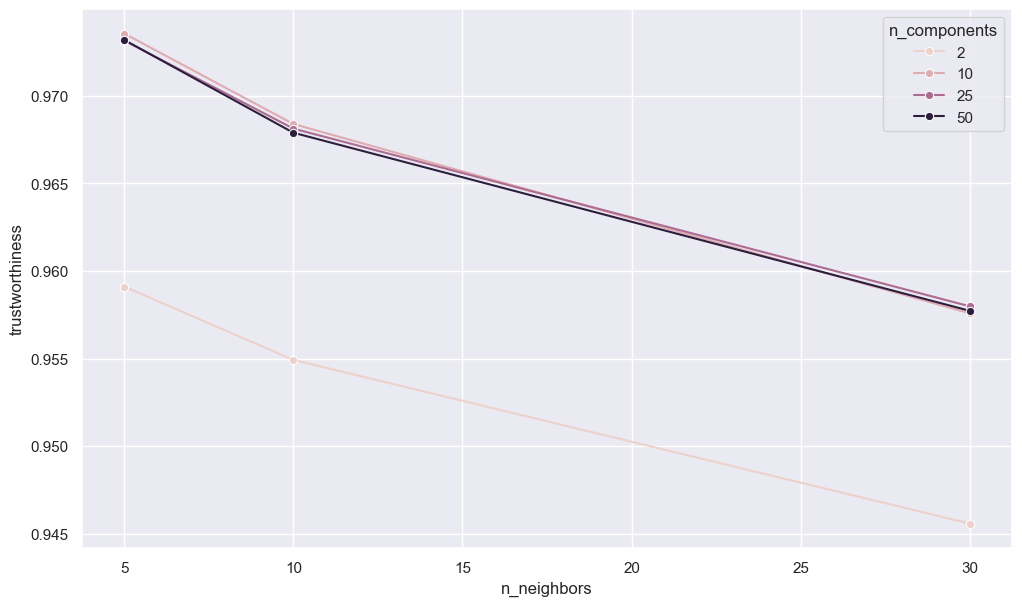

In [19]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=pd.DataFrame(results), x='n_neighbors', y='trustworthiness', hue='n_components', marker='o')
plt.show()

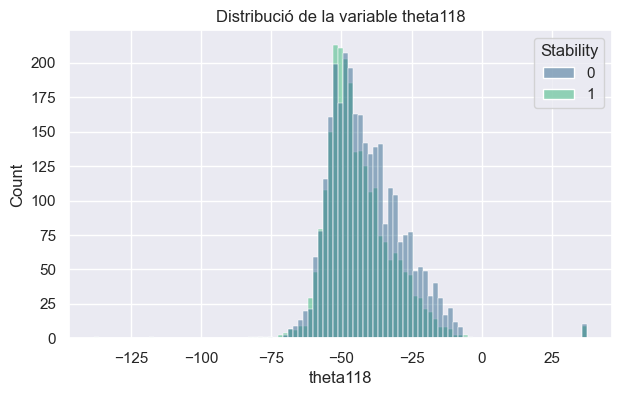

In [20]:
plt.figure(figsize=(7, 4))
sns.histplot(X_final, x="theta118", hue=y_scaled, palette="viridis");
plt.title("Distribució de la variable theta118")
plt.show()

In [21]:
X_umap = UMAP(
    n_components=best['n_components'], 
    n_neighbors=best['n_neighbors'], 
    metric='cosine',
    n_jobs=-1,
    low_memory=True,
).fit_transform(X_pca)

In [22]:
reducer = UMAP(n_components=2, n_neighbors=5, n_jobs=-1)
reducer_orig = UMAP(n_components=2, n_neighbors=5, n_jobs=-1)
embedding = reducer.fit_transform(X_pca)
embedding_orig = reducer_orig.fit_transform(X_scaled)

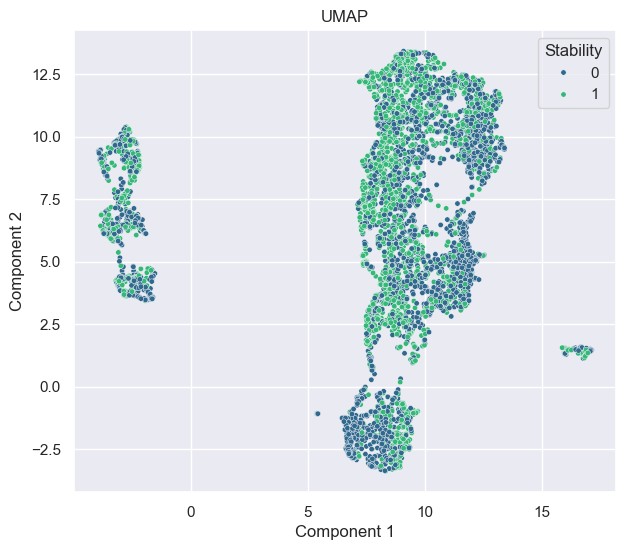

In [23]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=y_scaled, s=15, palette="viridis");
plt.title('UMAP')
plt.ylabel('Component 2')
plt.xlabel('Component 1')
plt.show()

## 5. K-Means

<p align="left">
<img src="img/kmeans.png" alt="PCA plot" width="40%" style="float: right; margin-left: 100px; margin-right:100px;">

Intenta dividir les dades en k clústers.

Objectius:

- Veure si es poden dividir les dades en estable o no estable

Limitacions:

- Cal especificar k prèviament.
- Sensible a outliers
- Intenta crear clústers de mida similar (s'han de balancejar les dades).
- Només detecta clústers de forma esferoidal
- Resultats no deterministes, seed diferent => resultats diferents

Silouete method i elbow

</p>


In [25]:
from sklearn.neighbors import KNeighborsClassifier

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, stratify=y_scaled)

knn =  KNeighborsClassifier()
param = {'n_neighbors': Integer(1, 20),
         'weights': Categorical(['uniform', 'distance']),
         'metric': Categorical(['l2', 'l1', 'cosine'])}
bayes_knn = BayesSearchCV(knn, param, n_iter=20, cv=3, n_jobs=-1, random_state=42)
bayes_knn.fit(X_train_knn, y_train_knn)

BayesSearchCV(cv=3, estimator=KNeighborsClassifier(), n_iter=20, n_jobs=-1,
              random_state=42,
              search_spaces={'metric': Categorical(categories=('l2', 'l1', 'cosine'), prior=None),
                             'n_neighbors': Integer(low=1, high=20, prior='uniform', transform='normalize'),
                             'weights': Categorical(categories=('uniform', 'distance'), prior=None)})

In [25]:
print(classification_report(y_test_knn, bayes_knn.predict(X_test_knn)))

              precision    recall  f1-score   support

           0       0.72      0.69      0.70       596
           1       0.64      0.67      0.65       490

    accuracy                           0.68      1086
   macro avg       0.68      0.68      0.68      1086
weighted avg       0.68      0.68      0.68      1086



Per n_clusters = 2, silhouette_score = 0.29814570415564867


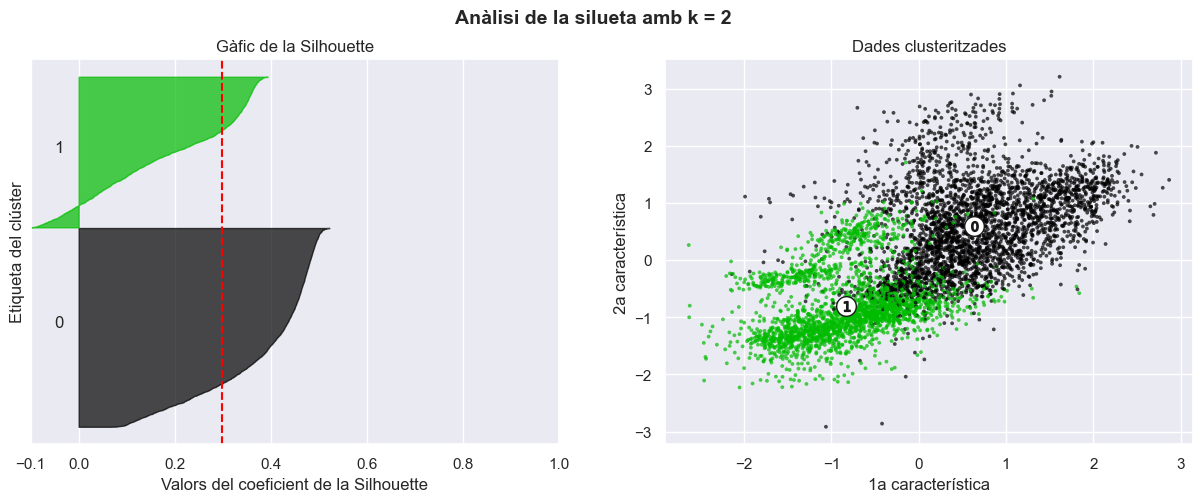

Per n_clusters = 3, silhouette_score = 0.21941373585949753


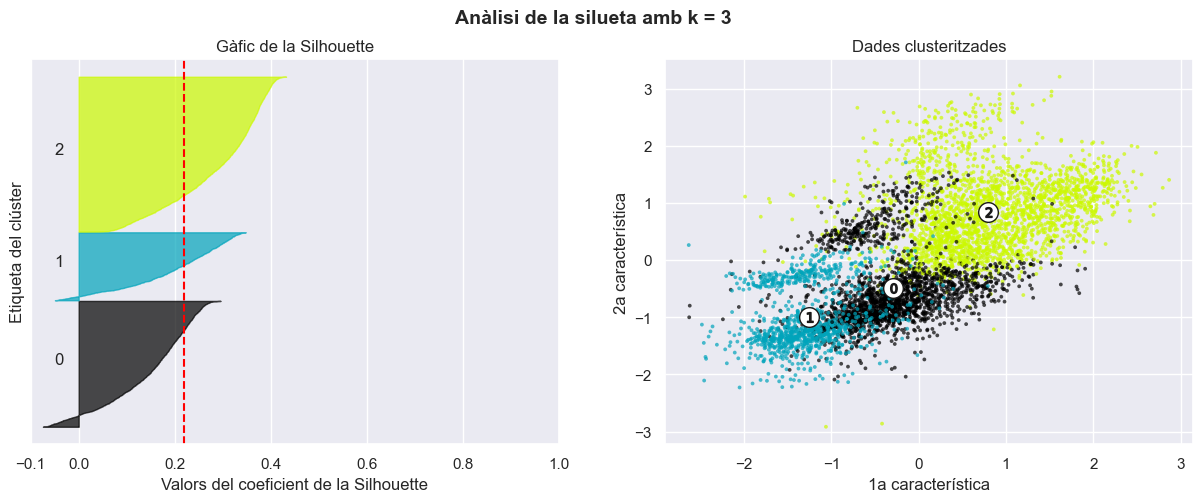

Per n_clusters = 4, silhouette_score = 0.18624023070264112


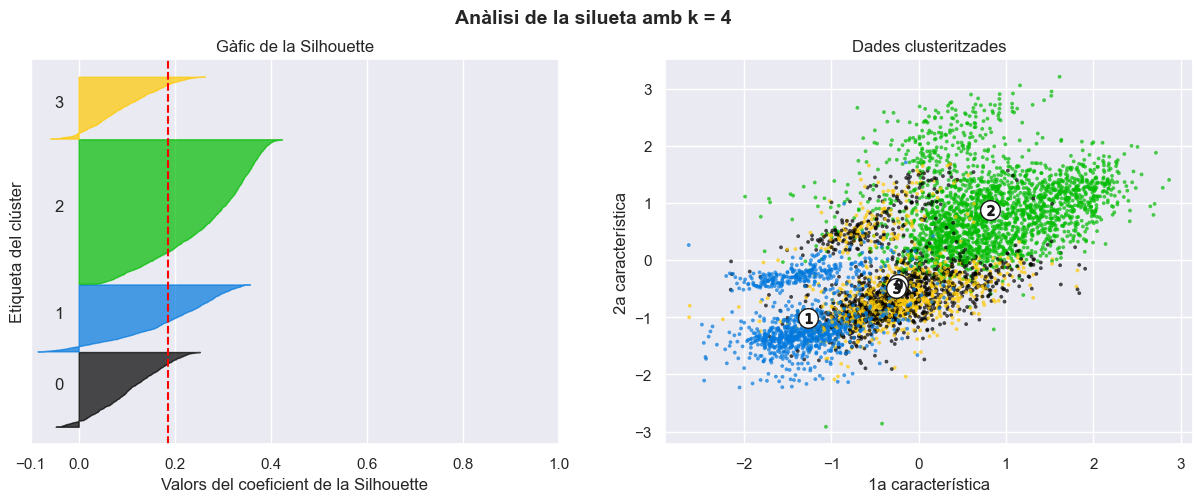

Per n_clusters = 5, silhouette_score = 0.16749549760013635


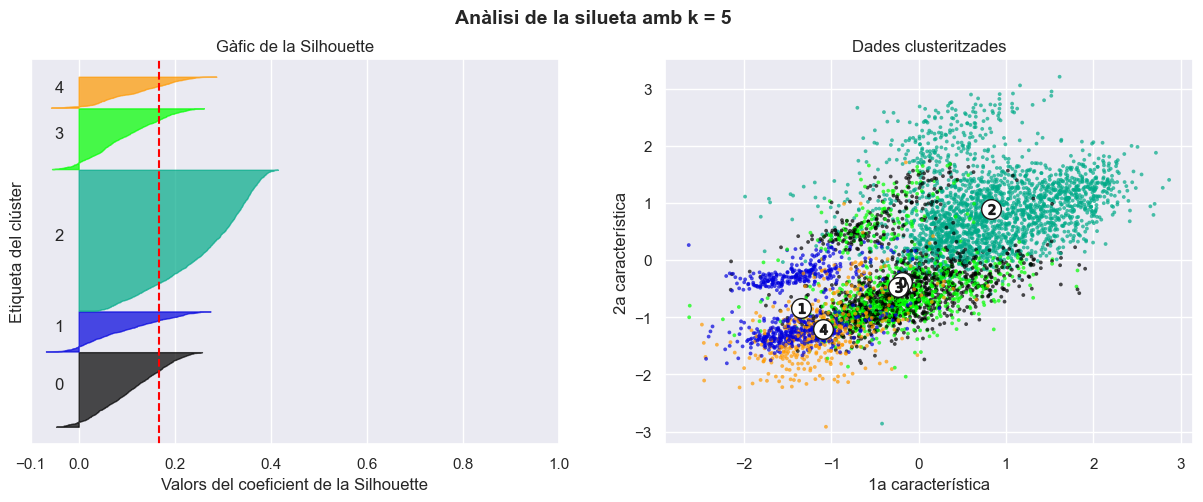

Per n_clusters = 6, silhouette_score = 0.11524621988687732


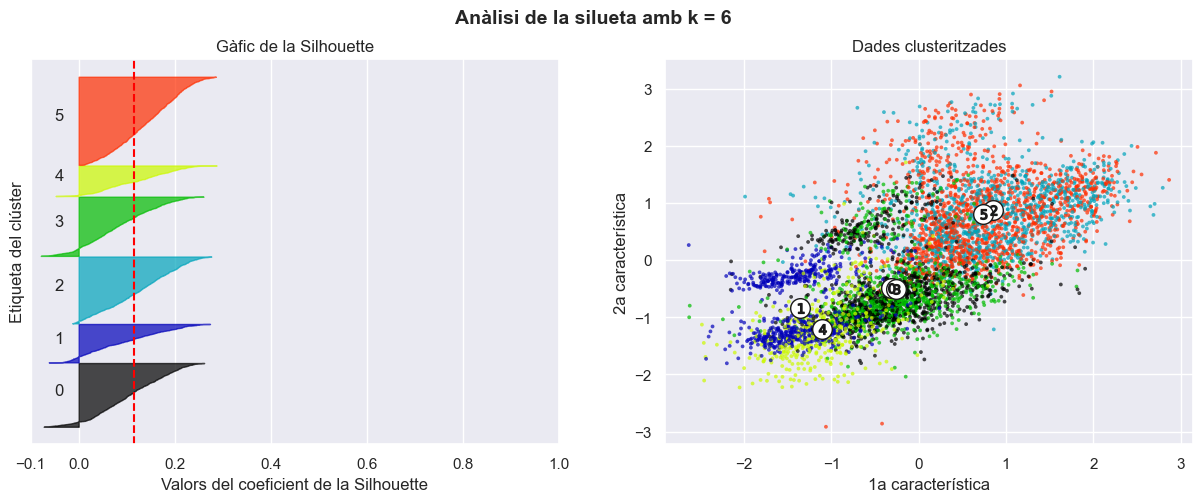

Per n_clusters = 7, silhouette_score = 0.11816565853147304


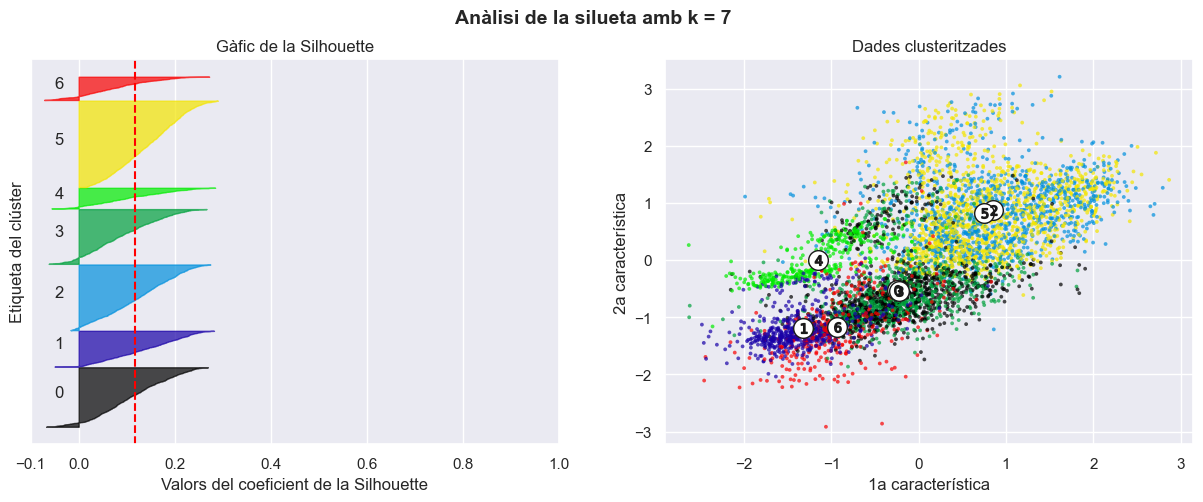

Per n_clusters = 8, silhouette_score = 0.10984741799868109


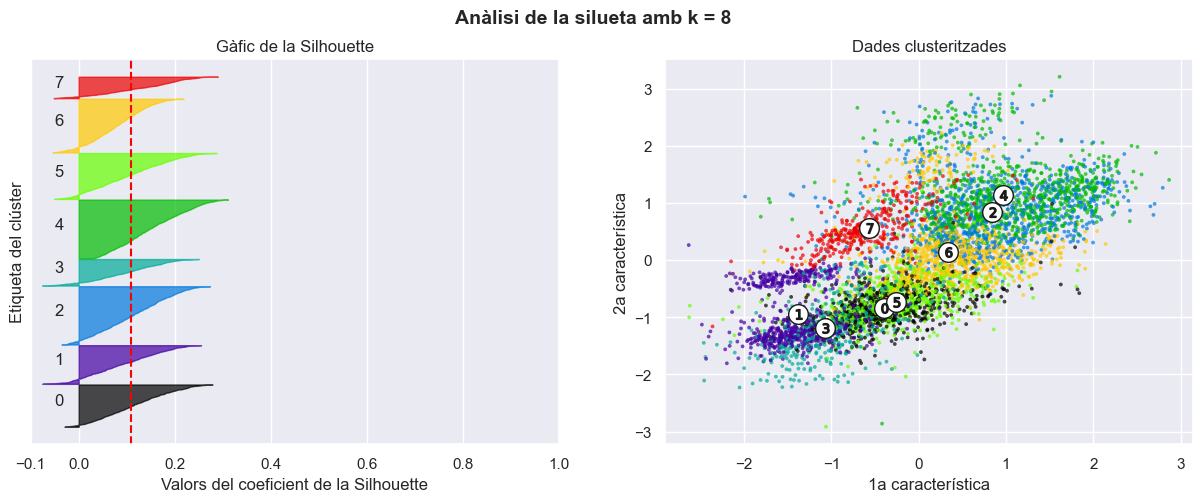

Per n_clusters = 9, silhouette_score = 0.10697155912245394


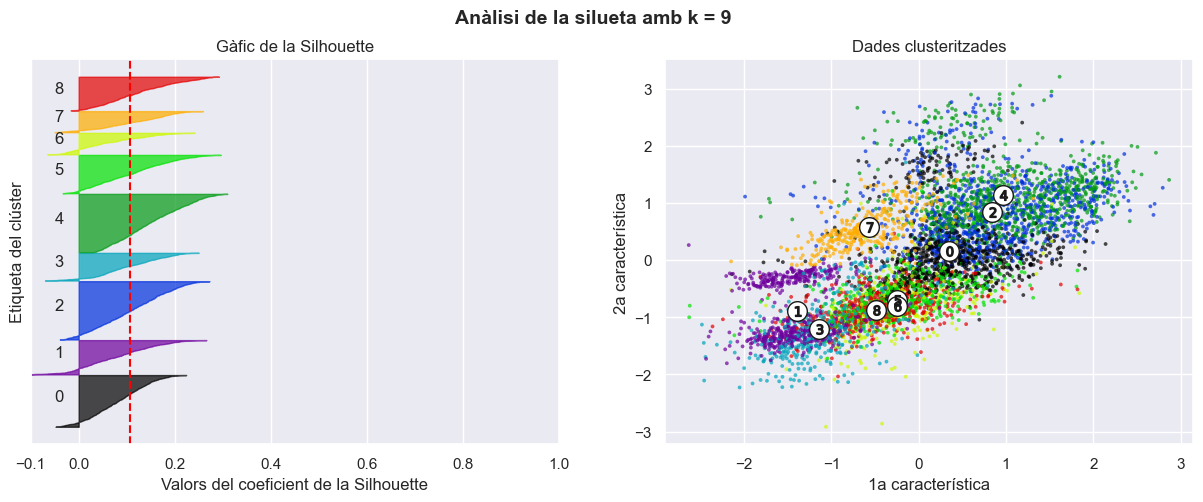

In [141]:
range_clusters = range(2, 10)
distortion = []
inertia = []

for n_clusters in range_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_xlim(-0.1, 1)
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    clusterer_labels = clusterer.fit_predict(X_scaled)
    distortion.append(sum(np.min(cdist(X_scaled, clusterer.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0])
    inertia.append(clusterer.inertia_)
    
    silhouette_avg = silhouette_score(X_scaled, clusterer_labels)
    print(
        f"Per n_clusters = {n_clusters}, silhouette_score = {silhouette_avg}"
    )
    sample_silhouette_values = silhouette_samples(X_scaled, clusterer_labels)
    y_lower = 10

    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[clusterer_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax1.set_title("Gàfic de la Silhouette")
    ax1.set_xlabel("Valors del coeficient de la Silhouette")
    ax1.set_ylabel("Etiqueta del clúster")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = plt.cm.nipy_spectral(clusterer_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        marker=".",
        s=30,
        lw=0,
        alpha=0.7,
        c=colors,
        edgecolor="k",
    )
    centers = clusterer.cluster_centers_
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(
            c[0],
            c[1],
            marker="$%d$" % i,
            alpha=1,
            s=50,
            edgecolor="k",
        )
    ax2.set_title("Dades clusteritzades")
    ax2.set_xlabel("1a característica")
    ax2.set_ylabel("2a característica")
    plt.suptitle(
        f"Anàlisi de la silueta amb k = {n_clusters}",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()

In [44]:
cluster_purity = []
range_clusters = range(2, 15)
for n_clusters in range_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    purity = 0
    for cluster in range(n_clusters):
        indices = np.where(cluster_labels == cluster)[0]
        if len(indices) == 0:
            continue
        true_labels = y_scaled.iloc[indices]
        most_common = true_labels.value_counts().idxmax()
        purity += (true_labels == most_common).sum()
    purity /= len(y_scaled)
    cluster_purity.append(purity)
    print(f'Purity per n_clusters={n_clusters}: {purity:.4f}')

Purity per n_clusters=2: 0.6435
Purity per n_clusters=3: 0.6468
Purity per n_clusters=4: 0.6426
Purity per n_clusters=5: 0.6455
Purity per n_clusters=6: 0.6463
Purity per n_clusters=7: 0.6494
Purity per n_clusters=8: 0.6599
Purity per n_clusters=9: 0.6590
Purity per n_clusters=10: 0.6505
Purity per n_clusters=11: 0.6527
Purity per n_clusters=12: 0.6629
Purity per n_clusters=13: 0.6641
Purity per n_clusters=14: 0.6654


In [45]:
plt.figure(figsize=(10,5))
sns.lineplot(x=range_clusters, y=distortion, marker='o', label='Distortion')
plt.show()
plt.figure(figsize=(10,5))
sns.lineplot(x=range_clusters, y=inertia, marker='o', label='Inertia')
plt.show()

NameError: name 'distortion' is not defined

<Figure size 1000x500 with 0 Axes>

In [50]:
results = pd.DataFrame({'k': [], 'acc': []})
for k in range(2, 20):
    knn = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    cluster_to_class = {}
    for cluster in range(k):
        indices = np.where(knn == cluster)[0]
        labels = y_scaled.iloc[indices]
        most_common = labels.value_counts().idxmax()
        cluster_to_class[cluster] = most_common

    assigned_class = np.array([cluster_to_class[c] for c in knn])
    diff = y_scaled.values - assigned_class
    accuracy = np.sum(diff == 0) / len(y_scaled)
    results = results.append({'k': k, 'acc': accuracy}, ignore_index=True)


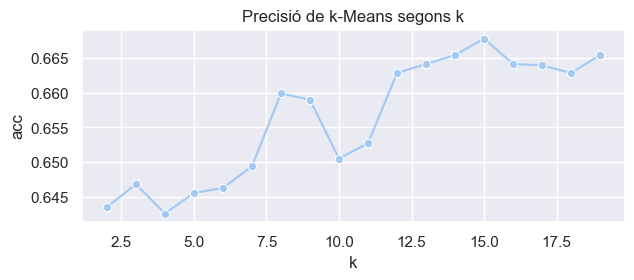

In [51]:
plt.figure(figsize=(7,2.5))
sns.lineplot(data=results, x='k', y='acc', marker='o', palette="viridis")

plt.title('Precisió de k-Means segons k')
plt.show()

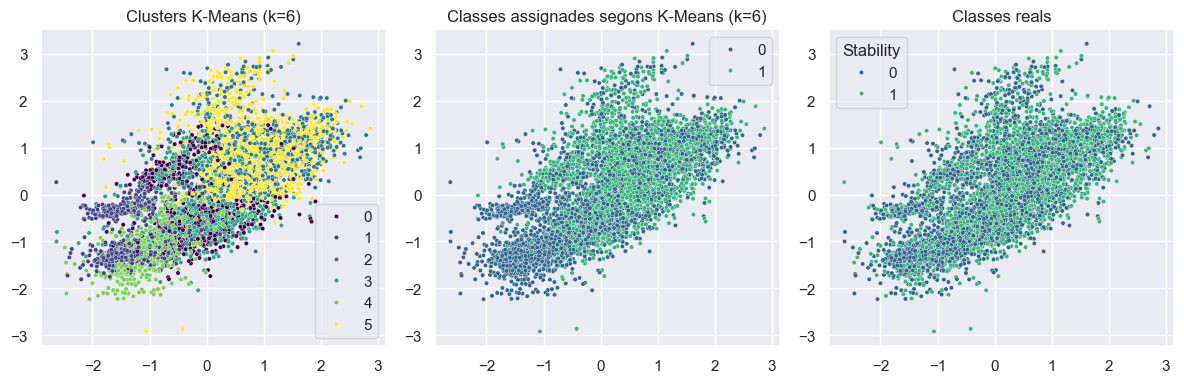

In [ ]:
knn = KMeans(n_clusters=6, random_state=42).fit_predict(X_scaled)
cluster_to_class = {}
for cluster in range(6):
    indices = np.where(knn == cluster)[0]
    labels = y_scaled.iloc[indices]
    most_common = labels.value_counts().idxmax()
    cluster_to_class[cluster] = most_common

assigned_class = np.array([cluster_to_class[c] for c in knn])

fig, ax = plt.subplots(1,3, figsize=(12,4))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=knn, palette="viridis", s=10, ax=ax[0]);
ax[0].set_title('Clusters K-Means (k=6)')
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=assigned_class, palette="viridis", s=10, ax=ax[1]);
ax[1].set_title('Classes assignades segons K-Means (k=6)')
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_scaled, palette="viridis", s=10, ax=ax[2]);
ax[2].set_title('Classes reals')
plt.tight_layout()
plt.show()


## 6. DBSCAN - Density-Based Spatial Clustering of Applications with Noise 

<p align="left">
<img src="img/dbscan.png" alt="PCA plot" width="35%" style="float: right; margin-left: 100px; margin-right:100px;">

Similar a k-Means, però agrupa punts que estan densament connectats i marca com a soroll aquells que no pertanyen a cap clúster.

Objectius:

- Veure si es poden dividir les dades en estable o no estable
- Detectar soroll i outliers

Limitacions:

- Sensible als hiperparàmetres
- Dificultat per adaptar-se a densitats molt variables
- Cost

</p>

### Silhouette per DBSCAN

In [290]:
dades = tsne
dbscan = DBSCAN(eps=2.15, min_samples=10).fit(dades)
labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')


Estimated number of clusters: 25
Estimated number of noise points: 484


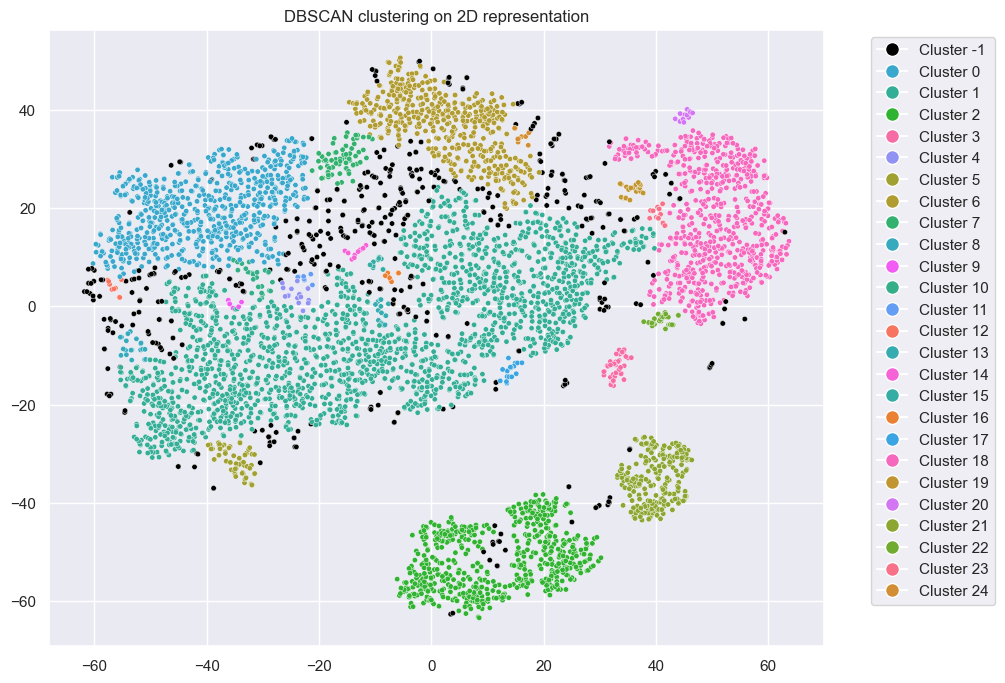

In [296]:
import random
unique_labels = np.unique(labels)
normal_labels = unique_labels[unique_labels != -1]
palette = sns.color_palette("husl", len(unique_labels))
random.shuffle(palette, random.seed(42))
color_map = {-1: (0, 0, 0)} 
color_map.update({lab: col for lab, col in zip(normal_labels, palette)})

colors = [color_map[l] for l in labels]

plt.figure(figsize=(10, 8))
sns.scatterplot(x=dades[:,0], y=dades[:,1], s=15, c=colors);
plt.title('DBSCAN clustering on 2D representation')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {lab}', markerfacecolor=color_map[lab], markersize=10) for lab in unique_labels], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

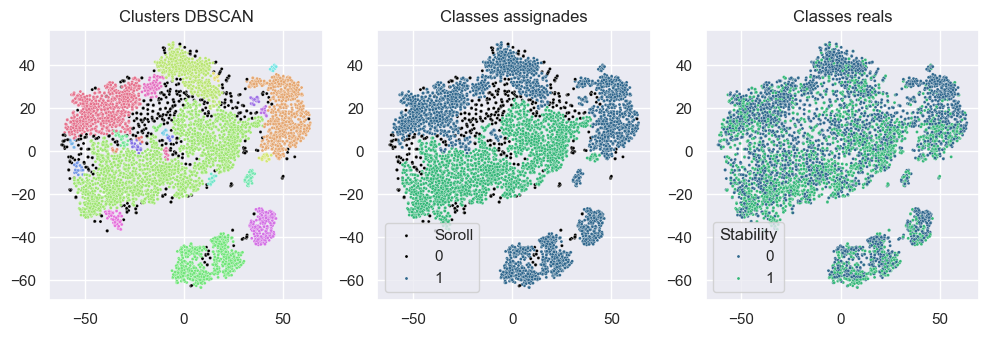

In [315]:
import matplotlib.colors as mcolors
dbscan = DBSCAN(eps=2.15, min_samples=10).fit(dades)
labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
cluster_to_class = {}
for cluster in range(n_clusters_):
    indices = np.where(labels == cluster)[0]
    true_labels_cluster = y_scaled.iloc[indices]
    most_common = true_labels_cluster.value_counts().idxmax()
    cluster_to_class[cluster] = most_common
assigned_class = np.array([cluster_to_class[c] if c != -1 else -1 for c in labels])
fig, ax = plt.subplots(1,3, figsize=(12,3.5))
palette = sns.color_palette("viridis", 2)
color_map[0] = palette[0]
color_map[1] = palette[1]
color_map[-1] = (0, 0, 0)

unique_labels = np.unique(labels)
normal_labels = unique_labels[unique_labels != -1]
def generate_distinct_colors(n):
    hsv_colors = [(i / n, 0.5, 0.9) for i in range(n)]
    rgb_colors = [tuple(int(c * 255) / 255 for c in mcolors.hsv_to_rgb(hsv)) for hsv in hsv_colors]
    return rgb_colors

palette2 = generate_distinct_colors(26)
random.shuffle(palette2)
color_map2 = {lab: col for lab, col in zip(normal_labels, palette2)}
color_map2[-1] = (0, 0, 0) 
colors = [color_map2[l] for l in labels]
sns.scatterplot(x=dades[:,0], y=dades[:,1], s=5, c=colors, ax=ax[0]);
ax[0].set_title('Clusters DBSCAN')
sns.scatterplot(x=dades[:,0], y=dades[:,1], s=5, hue=assigned_class, palette=color_map, ax=ax[1]);
sns.scatterplot(x=dades[:,0], y=dades[:,1], s=5, hue=y_scaled, palette=color_map, ax=ax[2]);
ax[1].set_title('Classes assignades')
ax[1].legend(["Soroll", 0, 1])
ax[2].set_title('Classes reals')
plt.show()

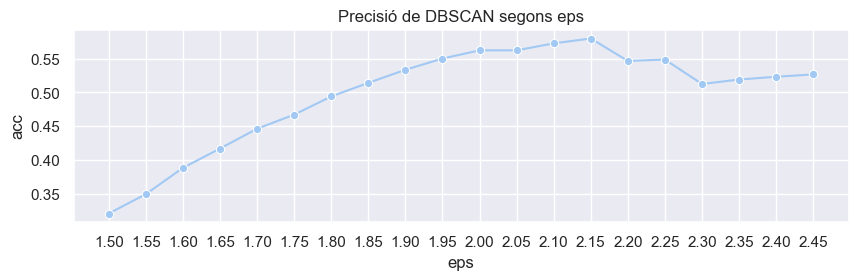

In [264]:
results = pd.DataFrame({'eps': [], 'acc': []})
for eps in np.arange(1.5, 2.5, 0.05):
    dbscan = DBSCAN(eps=eps, min_samples=10).fit(dades)
    labels = dbscan.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    cluster_to_class = {}
    for cluster in range(n_clusters_):
        indices = np.where(labels == cluster)[0]
        true_labels_cluster = y_scaled.iloc[indices]
        most_common = true_labels_cluster.value_counts().idxmax()
        cluster_to_class[cluster] = most_common
    assigned_class = np.array([cluster_to_class[c] if c != -1 else -1 for c in labels])
    diff = y_scaled.values - assigned_class
    accuracy = np.sum(diff == 0) / len(y_scaled)
    results = results.append({'eps': eps, 'acc': accuracy}, ignore_index=True)
plt.figure(figsize=(10,2.5))
sns.lineplot(data=results, x='eps', y='acc', marker='o', palette="viridis")
plt.xticks(np.arange(1.5, 2.5, 0.05))
plt.title('Precisió de DBSCAN segons eps')
plt.show()


In [222]:
from skopt.utils import use_named_args

space = [Real(0.1, 20, name='eps')]

def avg_puresa_clusters(labels, y):
    clusters_df = pd.DataFrame({'cluster': labels, 'stability': y})

    weighted_sum = 0
    total_points = 0

    for c in clusters_df['cluster'].unique():
        if c == -1:
            continue
        cluster = clusters_df[clusters_df['cluster'] == c]
        count = cluster['stability'].value_counts()
        p = count.max() / count.sum()
        n = len(cluster)
        weighted_sum += p * n
        total_points += n

    return weighted_sum / total_points if total_points > 0 else 0

@use_named_args(space)
def objective(eps):
    dbs = DBSCAN(eps=eps, min_samples=10).fit(dades)
    labels = dbs.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    puresa = avg_puresa_clusters(labels, y_scaled.values)

    noise_ratio = (np.sum(labels == -1) / len(labels))

    score = 3 * (-puresa) + 1 * noise_ratio

    return score

In [223]:
from skopt import gp_minimize

result = gp_minimize(
    func=objective,
    dimensions=space,
    acq_func='EI',
    n_calls=40,
    n_initial_points=8,
    random_state=0,
)

best_eps = result.x[0]
func_val = result.fun   

print(f'Best eps: {best_eps} with objective value: {func_val}')

Best eps: 2.1489310001408026 with objective value: -1.8196103540942286


## 8. Decision Tree

<p align="left">
<img src="img/dtree.png" alt="PCA plot" width="40%" style="float: right; margin-left: 100px; margin-right:100px;">

Model  que aprèn regles de decisió en forma d’arbre per classificar o predir valors.

Objectius:

- Veure a quines característiques  dona més importància l’arbre de decisió.

Limitacions:

- Alta variància: pot sobreajustar fàcilment
- Sensible a petites variacions de les dades
- No generalitza bé sense tècniques de regularització
- Si la precisió del classificador no és prou bona els resultats no tenen perquè ser rellevants

</p>


In [322]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, stratify=y_scaled)

param = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(2, 20),     
    'min_samples_leaf': Integer(1, 10),
    'splitter': Categorical(['best', 'random']),
    'max_leaf_nodes': Integer(5, 100)        
}

dt = DecisionTreeClassifier(random_state=42)
dt_bs = BayesSearchCV(dt, param, n_iter=50, cv=3, n_jobs=-1, random_state=42)
dt_bs.fit(X_train, y_train)

BayesSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
              n_jobs=-1, random_state=42,
              search_spaces={'criterion': Categorical(categories=('gini', 'entropy'), prior=None),
                             'max_depth': Integer(low=2, high=20, prior='uniform', transform='normalize'),
                             'max_leaf_nodes': Integer(low=5, high=100, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'splitter': Categorical(categories=('best', 'random'), prior=None)})

In [323]:
print(classification_report(y_test, dt_bs.predict(X_test), target_names=['Inestable', 'Estable']))

              precision    recall  f1-score   support

   Inestable       0.90      0.76      0.83       596
     Estable       0.76      0.90      0.82       490

    accuracy                           0.82      1086
   macro avg       0.83      0.83      0.82      1086
weighted avg       0.84      0.82      0.82      1086



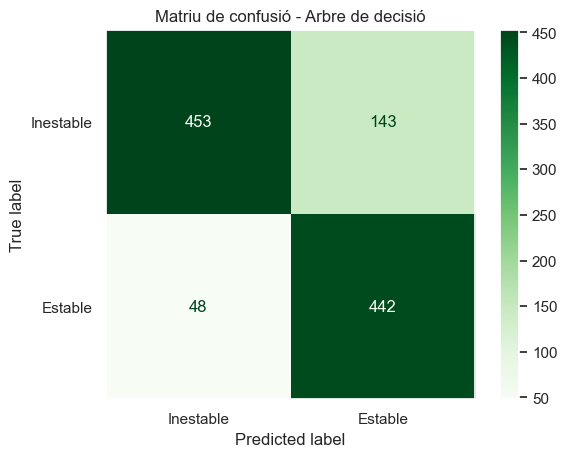

In [324]:
sns.set_style("dark")
ConfusionMatrixDisplay.from_estimator(dt_bs, X_test, y_test, display_labels=['Inestable','Estable'], cmap='Greens');
plt.title("Matriu de confusió - Arbre de decisió")
plt.show()

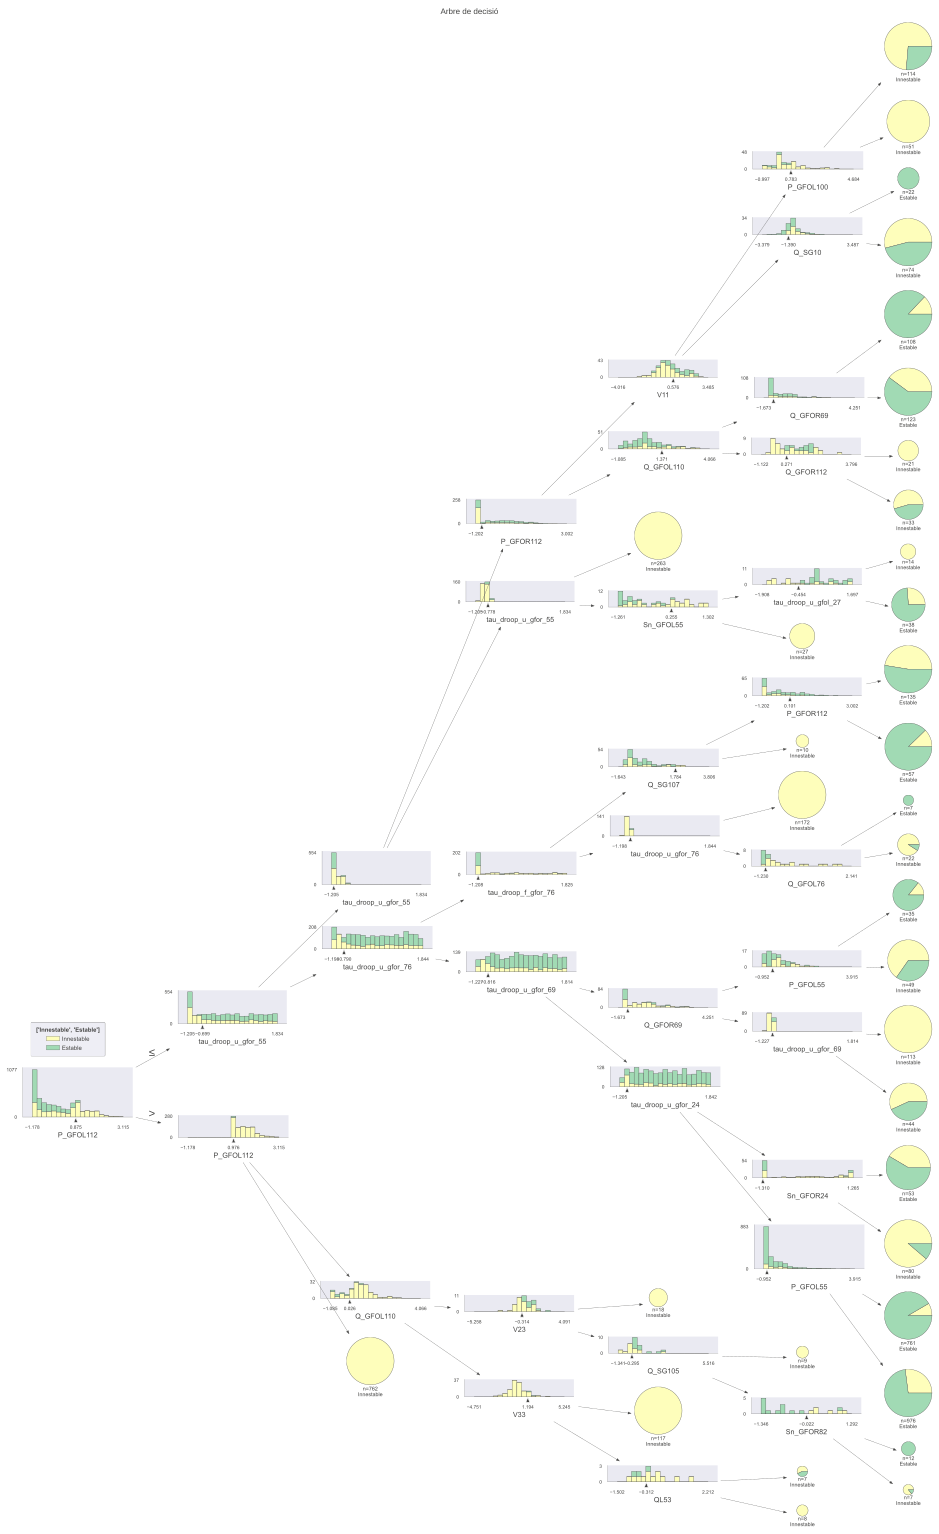

In [328]:
v_model = dtreeviz.model(
    dt_bs.best_estimator_,
    X_train= X_train,
    y_train= y_train,
    target_name=['Innestable', 'Estable'],
    feature_names = [c for c in X_final.columns],
    class_names=['Innestable', 'Estable']  
)
v_model.view(scale=0.8, title="Arbre de decisió", orientation='LR')

## 9. Gradient Boosting

<p align="left">
<img src="img/gradboost.png" alt="PCA plot" width="40%" style="float: right; margin-left: 100px; margin-right:100px;">

Similar a Decision Tree, construeixen arbres seqüencialment, cada un intentant corregir els errors del precedent.

Objectius:

- Veure a quines característiques  dona més importància l’arbre de decisió.

Limitacions:

- Sensible als hiperparàmetres
- Eficiencia
- Pot sobreajustar

</p>

> [!WARNING]
> Actualment gradient boosting triga una barbaritat de temps :( 

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, stratify=y_scaled)


gb = LGBMClassifier(random_state=42)
param = {
    'num_leaves': Integer(10, 90),
    'max_depth': Integer(3, 16),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'n_estimators': Integer(100, 800),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0)
}

gb_bs = BayesSearchCV(gb, param, n_iter=20, cv=3, n_jobs=-1, random_state=42, scoring='accuracy', verbose=False)
gb_bs.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 1958, number of negative: 2384
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 162953
[LightGBM] [Info] Number of data points in the train set: 4342, number of used features: 641
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.450944 -> initscore=-0.196856
[LightGBM] [Info] Start training from score -0.196856


BayesSearchCV(cv=3, estimator=LGBMClassifier(random_state=42), n_iter=20,
              n_jobs=-1, random_state=42, scoring='accuracy',
              search_spaces={'colsample_bytree': Real(low=0.6, high=1.0, prior='uniform', transform='normalize'),
                             'learning_rate': Real(low=0.01, high=0.2, prior='log-uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=16, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=800, prior='uniform', transform='normalize'),
                             'num_leaves': Integer(low=10, high=90, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')},
              verbose=False)

In [42]:
print(classification_report(y_test, gb_bs.predict(X_test), target_names=['Inestable', 'Estable']))

              precision    recall  f1-score   support

   Inestable       0.92      0.85      0.88       596
     Estable       0.83      0.90      0.87       490

    accuracy                           0.88      1086
   macro avg       0.87      0.88      0.88      1086
weighted avg       0.88      0.88      0.88      1086



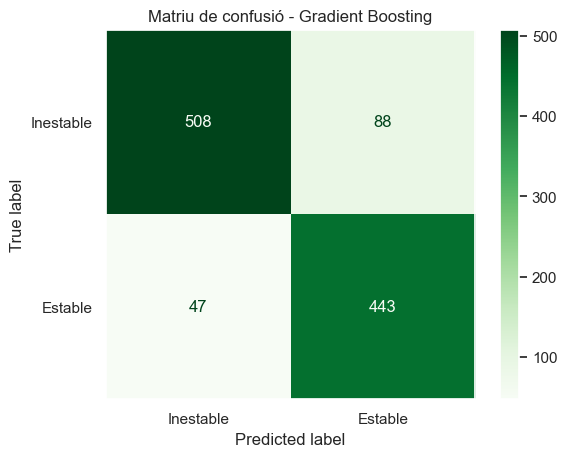

In [43]:
ConfusionMatrixDisplay.from_estimator(gb_bs, X_test, y_test, display_labels=['Inestable', 'Estable'], cmap='Greens');
plt.title("Matriu de confusió - Gradient Boosting")
plt.show()

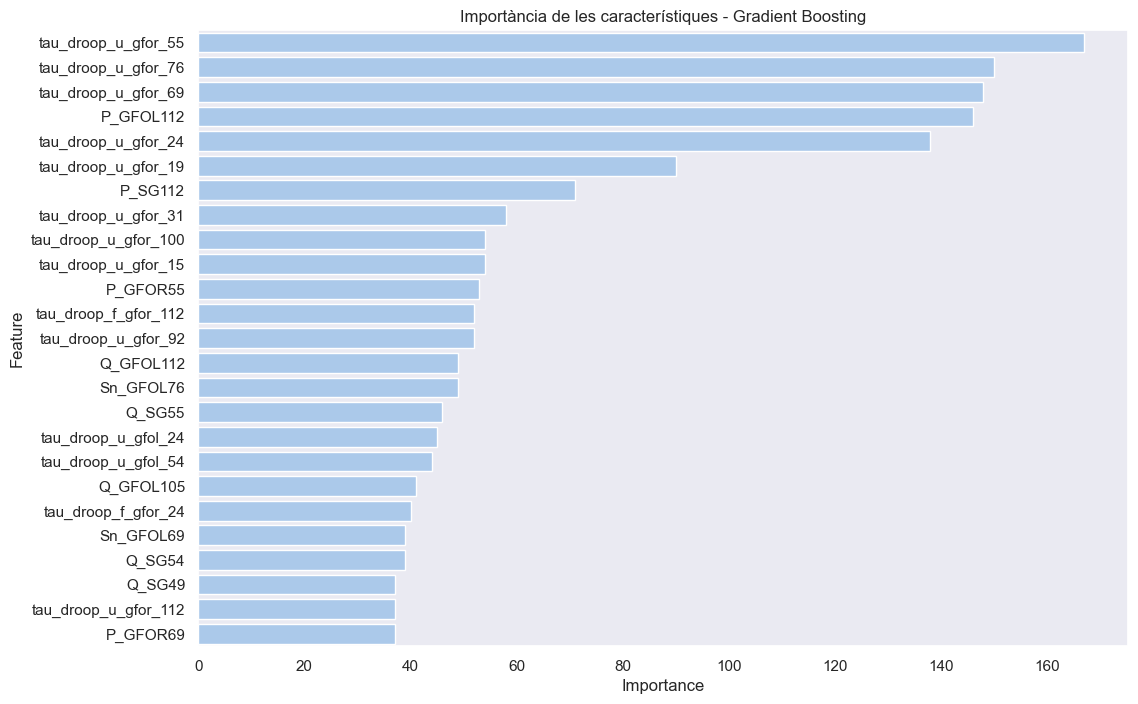

In [329]:
desc = gb_bs.best_estimator_.feature_importances_
feature_importances = pd.DataFrame({'Feature': X_final.columns, 'Importance': desc}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importances.head(25), x='Importance', y='Feature')
plt.title("Importància de les característiques - Gradient Boosting")
plt.show()


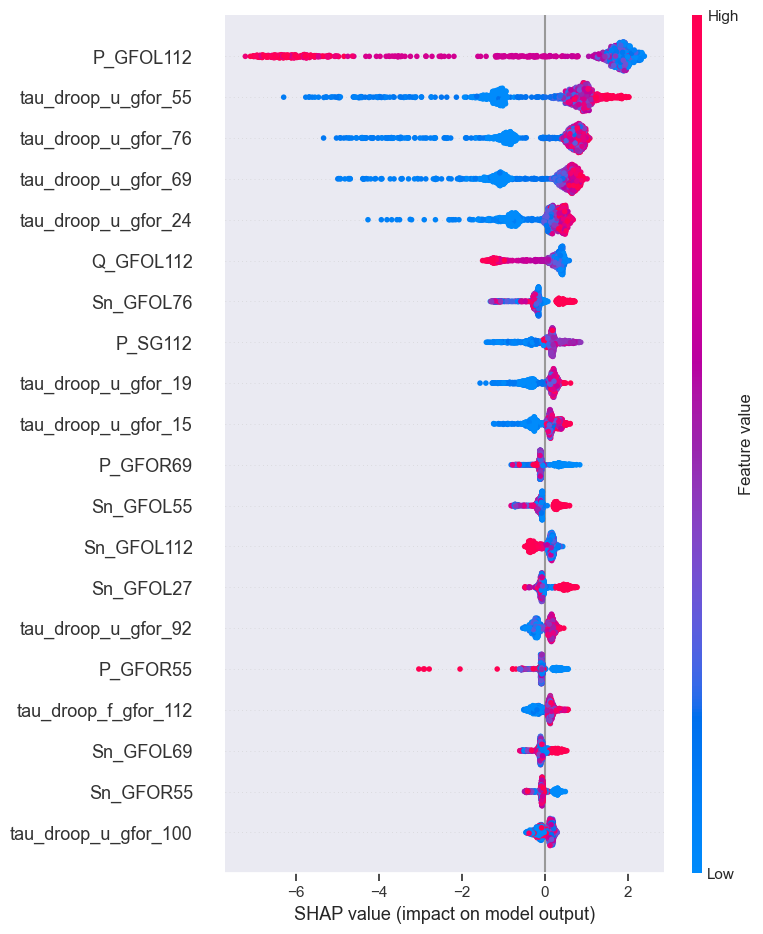

In [ ]:
explainer = shap.TreeExplainer(gb_bs.best_estimator_)
shap_values = explainer(X_test, y_test)
shap.summary_plot(shap_values, X_test, feature_names=X_final.columns)

In [46]:
shap.initjs()
shap.plots.force(shap_values[0:10], feature_names=X_final.columns)

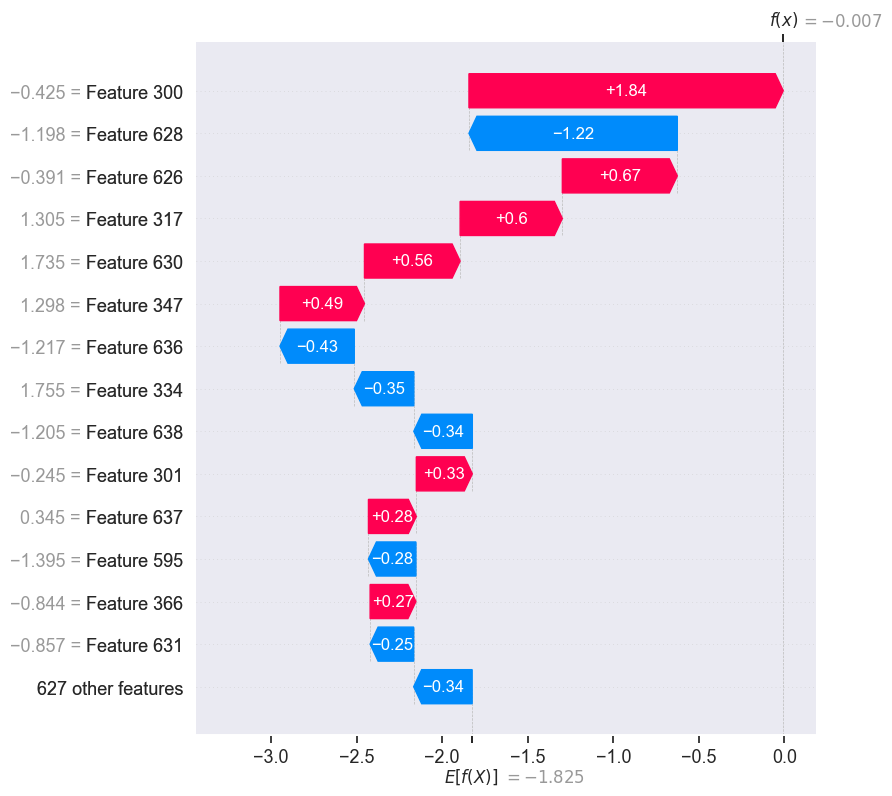

In [47]:
shap.initjs()
shap.plots.waterfall(shap_values[0], max_display=15)